# Raw GTEx + AHBA Sample Tensors

Raw input-space tensor views from `data/raw/gxp_samples.csv` (Tier A, CSV-driven via `build_native_tensor_view`).

1. **Standalone** — each dataset rendered on its own (`plot_gtex_tensor_voxels`).
2. **Joint** — both datasets stacked on the shared AHBA superset frame (`build_joint_tensor_view` → `plot_joint_tensor_voxels`), GTEx unmatched parcels flagged `future_imputation_mask` and rendered translucent.

The matched/harmonized/predicted stages live in `eval_gxp_samples_combat.ipynb` and `eval_gxp_samples_predictions.ipynb`. The native GTEx-tissue / AHBA-parcel reference renders are archived under `notebooks/arxiv/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eval_samples import (
    build_native_tensor_view,
    build_joint_tensor_view,
    plot_gtex_tensor_voxels,
    plot_joint_tensor_voxels,
    summarize_joint_selection,
)

set_academic_style()

In [2]:
SMALL = True
CSV_PATH = Path('data/raw/gxp_samples.csv')
ACTIVE_GENE_LIST = 'richiardi2015'  # richiardi2015, allgenes_stable_r0.2

# Joint frame: 'region_matched_superset' (both datasets share the AHBA axis).
# Standalone self-views use their own orderings (GTEx region_matched,
# AHBA region_matched_superset) — set in the build cell.
REGION_ORDERING = 'region_matched_superset'
MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'

# SMALL preset mirrors eval_gxp_samples_combat.ipynb for A/B comparability.
# SMALL=True   -> fast iteration (30 GTEx / 6 AHBA / 100 genes / 75 regions, DPI 300)
# SMALL=False  -> full-density figure (200 GTEx / 6 AHBA / full panel / full superset, DPI 400)
N_GTEX_SUBJECTS = 40 if SMALL else 200
N_AHBA_SUBJECTS = 6
N_GENES = 100 if SMALL else None
N_REGIONS = 80 if SMALL else None

MIN_REGIONS_PER_SUBJECT = 5
RANDOM_SEED = 42

# Subject-axis stacking: AHBA first (lower z) so GTEx renders on top.
STACK_ORDER = ('AHBA', 'GTEx')

# Render knobs
MISSING_ALPHA = 1.0
FUTURE_IMPUTATION_ALPHA = 0.3   # translucent gray on GTEx padded (no-data) cells
# 'two_pass'  -> opaque cells painted first, translucent slab overlaid (cleaner seam)
# 'single_pass' -> original behavior; one voxel call with mixed alphas (shows the artifact)
MASK_RENDER_MODE = 'single_pass'

FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 300 if SMALL else 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0

SUBJECT_TICK_STEP = 1
GENE_TICK_STEP = 10
REGION_TICK_STEP = 1
TICK_LABEL_PAD = -3.0

SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'

SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False

SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False

SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = False
DATASET_GAP = 1

## Build per-dataset views on the shared AHBA superset frame

Both views are built from the same CSV with identical gene panel, seed, and matching policy, so they land on the exact same region/gene axes. The GTEx superset carries `future_imputation_mask` on the unmatched AHBA parcels.

In [3]:
shared_kwargs = dict(
    gene_panel=ACTIVE_GENE_LIST,
    n_genes=N_GENES,
    min_regions_per_subject=MIN_REGIONS_PER_SUBJECT,
    random_seed=RANDOM_SEED,
    matching_policy=MATCHING_POLICY,
    matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    gtex_rep_mode=GTEX_REP_MODE,
    gtex_hemi_mode=GTEX_HEMI_MODE,
)

# Self / standalone views — different region frame per dataset:
#   GTEx self -> region_matched (its matched tissues only)
#   AHBA self -> region_matched_superset, N_REGIONS parcels
gtex_self = build_native_tensor_view(
    CSV_PATH, dataset='GTEx', region_ordering='region_matched',
    n_subjects=N_GTEX_SUBJECTS, **shared_kwargs,
)
ahba_self = build_native_tensor_view(
    CSV_PATH, dataset='AHBA', region_ordering='region_matched_superset',
    n_regions=N_REGIONS, n_subjects=N_AHBA_SUBJECTS, **shared_kwargs,
)

# Joint views — both on the shared AHBA superset frame (AHBA superset == ahba_self).
gtex_view = build_native_tensor_view(
    CSV_PATH, dataset='GTEx', region_ordering='region_matched_superset',
    n_regions=N_REGIONS, n_subjects=N_GTEX_SUBJECTS, **shared_kwargs,
)
ahba_view = ahba_self

print(f'gtex_self : {gtex_self.values.shape}  axis={gtex_self.region_axis_kind}  stage={gtex_self.pipeline_stage!r}')
print(f'ahba_self : {ahba_self.values.shape}  axis={ahba_self.region_axis_kind}  stage={ahba_self.pipeline_stage!r}')
print(f'gtex_view : {gtex_view.values.shape}  axis={gtex_view.region_axis_kind}  (joint)')
print(f'ahba_view : {ahba_view.values.shape}  axis={ahba_view.region_axis_kind}  (joint)')
print(f'joint regions identical: {gtex_view.regions == ahba_view.regions}; genes identical: {gtex_view.genes == ahba_view.genes}')


/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:868: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:868: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:868: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


gtex_self : (40, 12, 97)  axis=gtex_tissue  stage='native_tissue'
ahba_self : (6, 80, 97)  axis=ahba_parcel  stage='native_parcel'
gtex_view : (40, 80, 97)  axis=ahba_parcel  (joint)
ahba_view : (6, 80, 97)  axis=ahba_parcel  (joint)
joint regions identical: True; genes identical: True


## Standalone single-dataset views

Each dataset rendered on its own via `plot_gtex_tensor_voxels`. GTEx shows the matched parcels as observed expression and the unmatched AHBA parcels as translucent future-imputation padding; AHBA shows its observed parcels with missing cells solid gray.

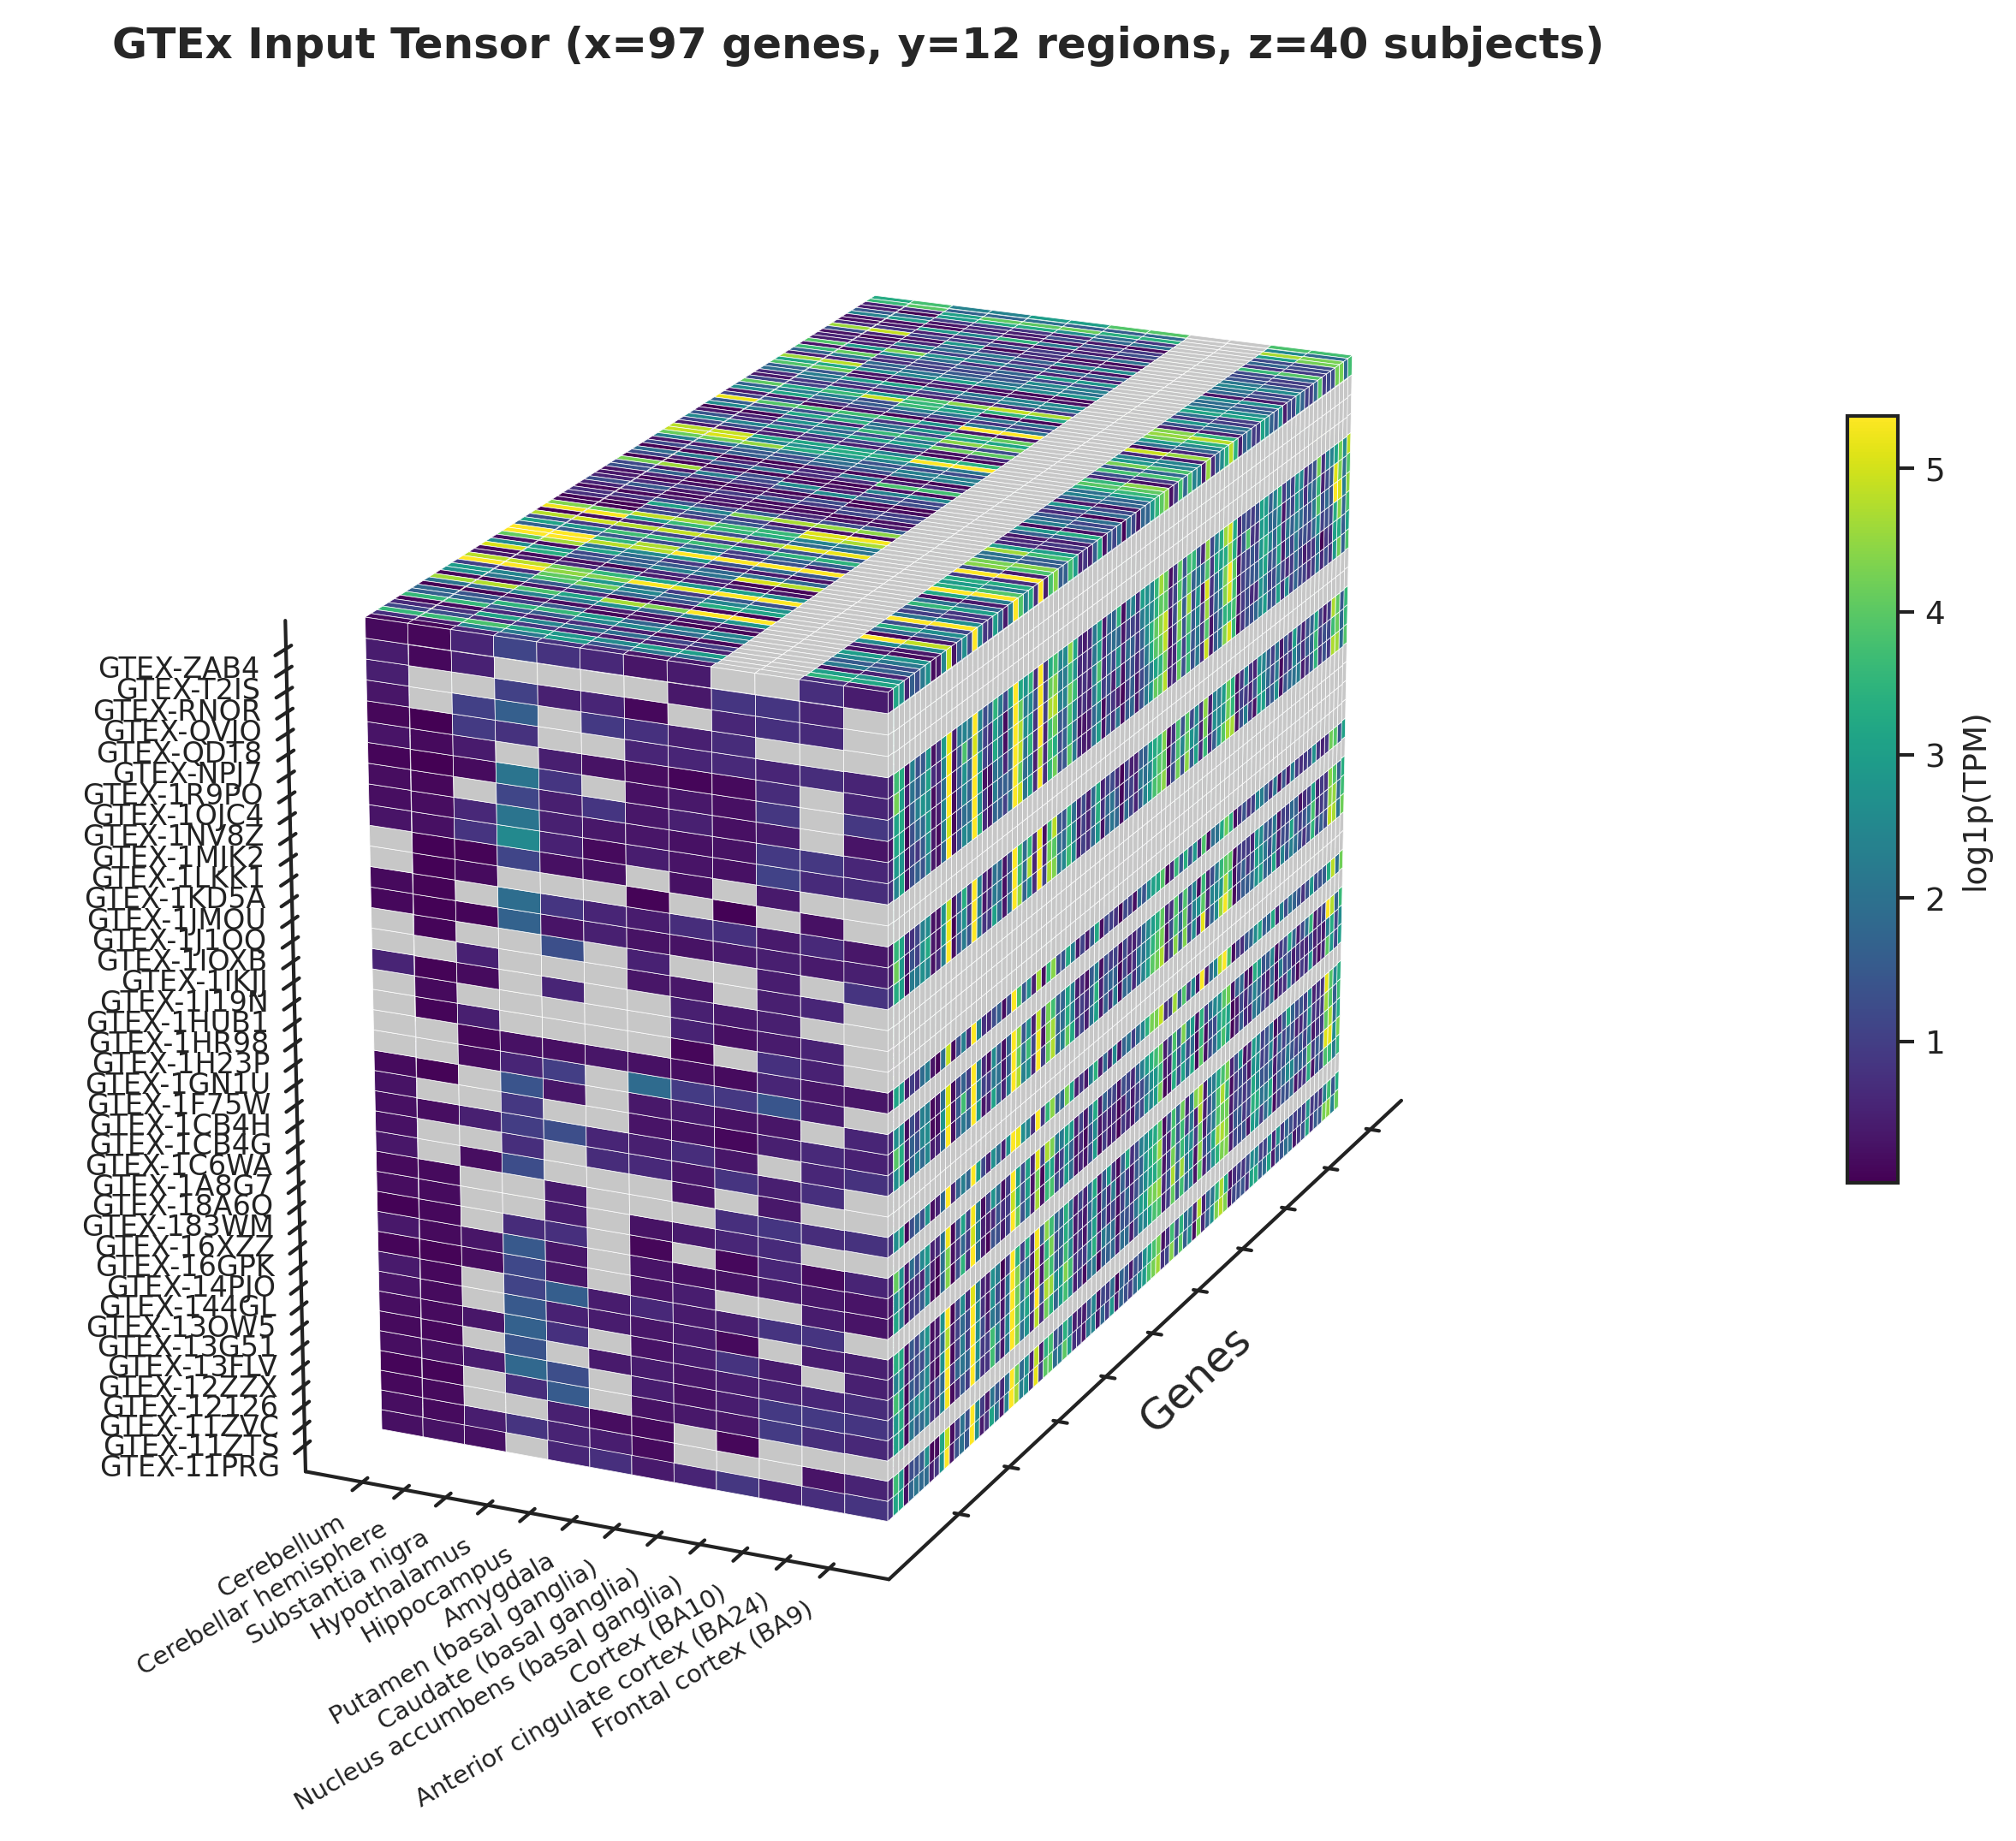

In [4]:
fig, ax = plot_gtex_tensor_voxels(
    gtex_self,
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP,
    region_tick_step=REGION_TICK_STEP, tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, show_legend=SHOW_LEGEND,
    mask_render_mode=MASK_RENDER_MODE,
)
plt.show()

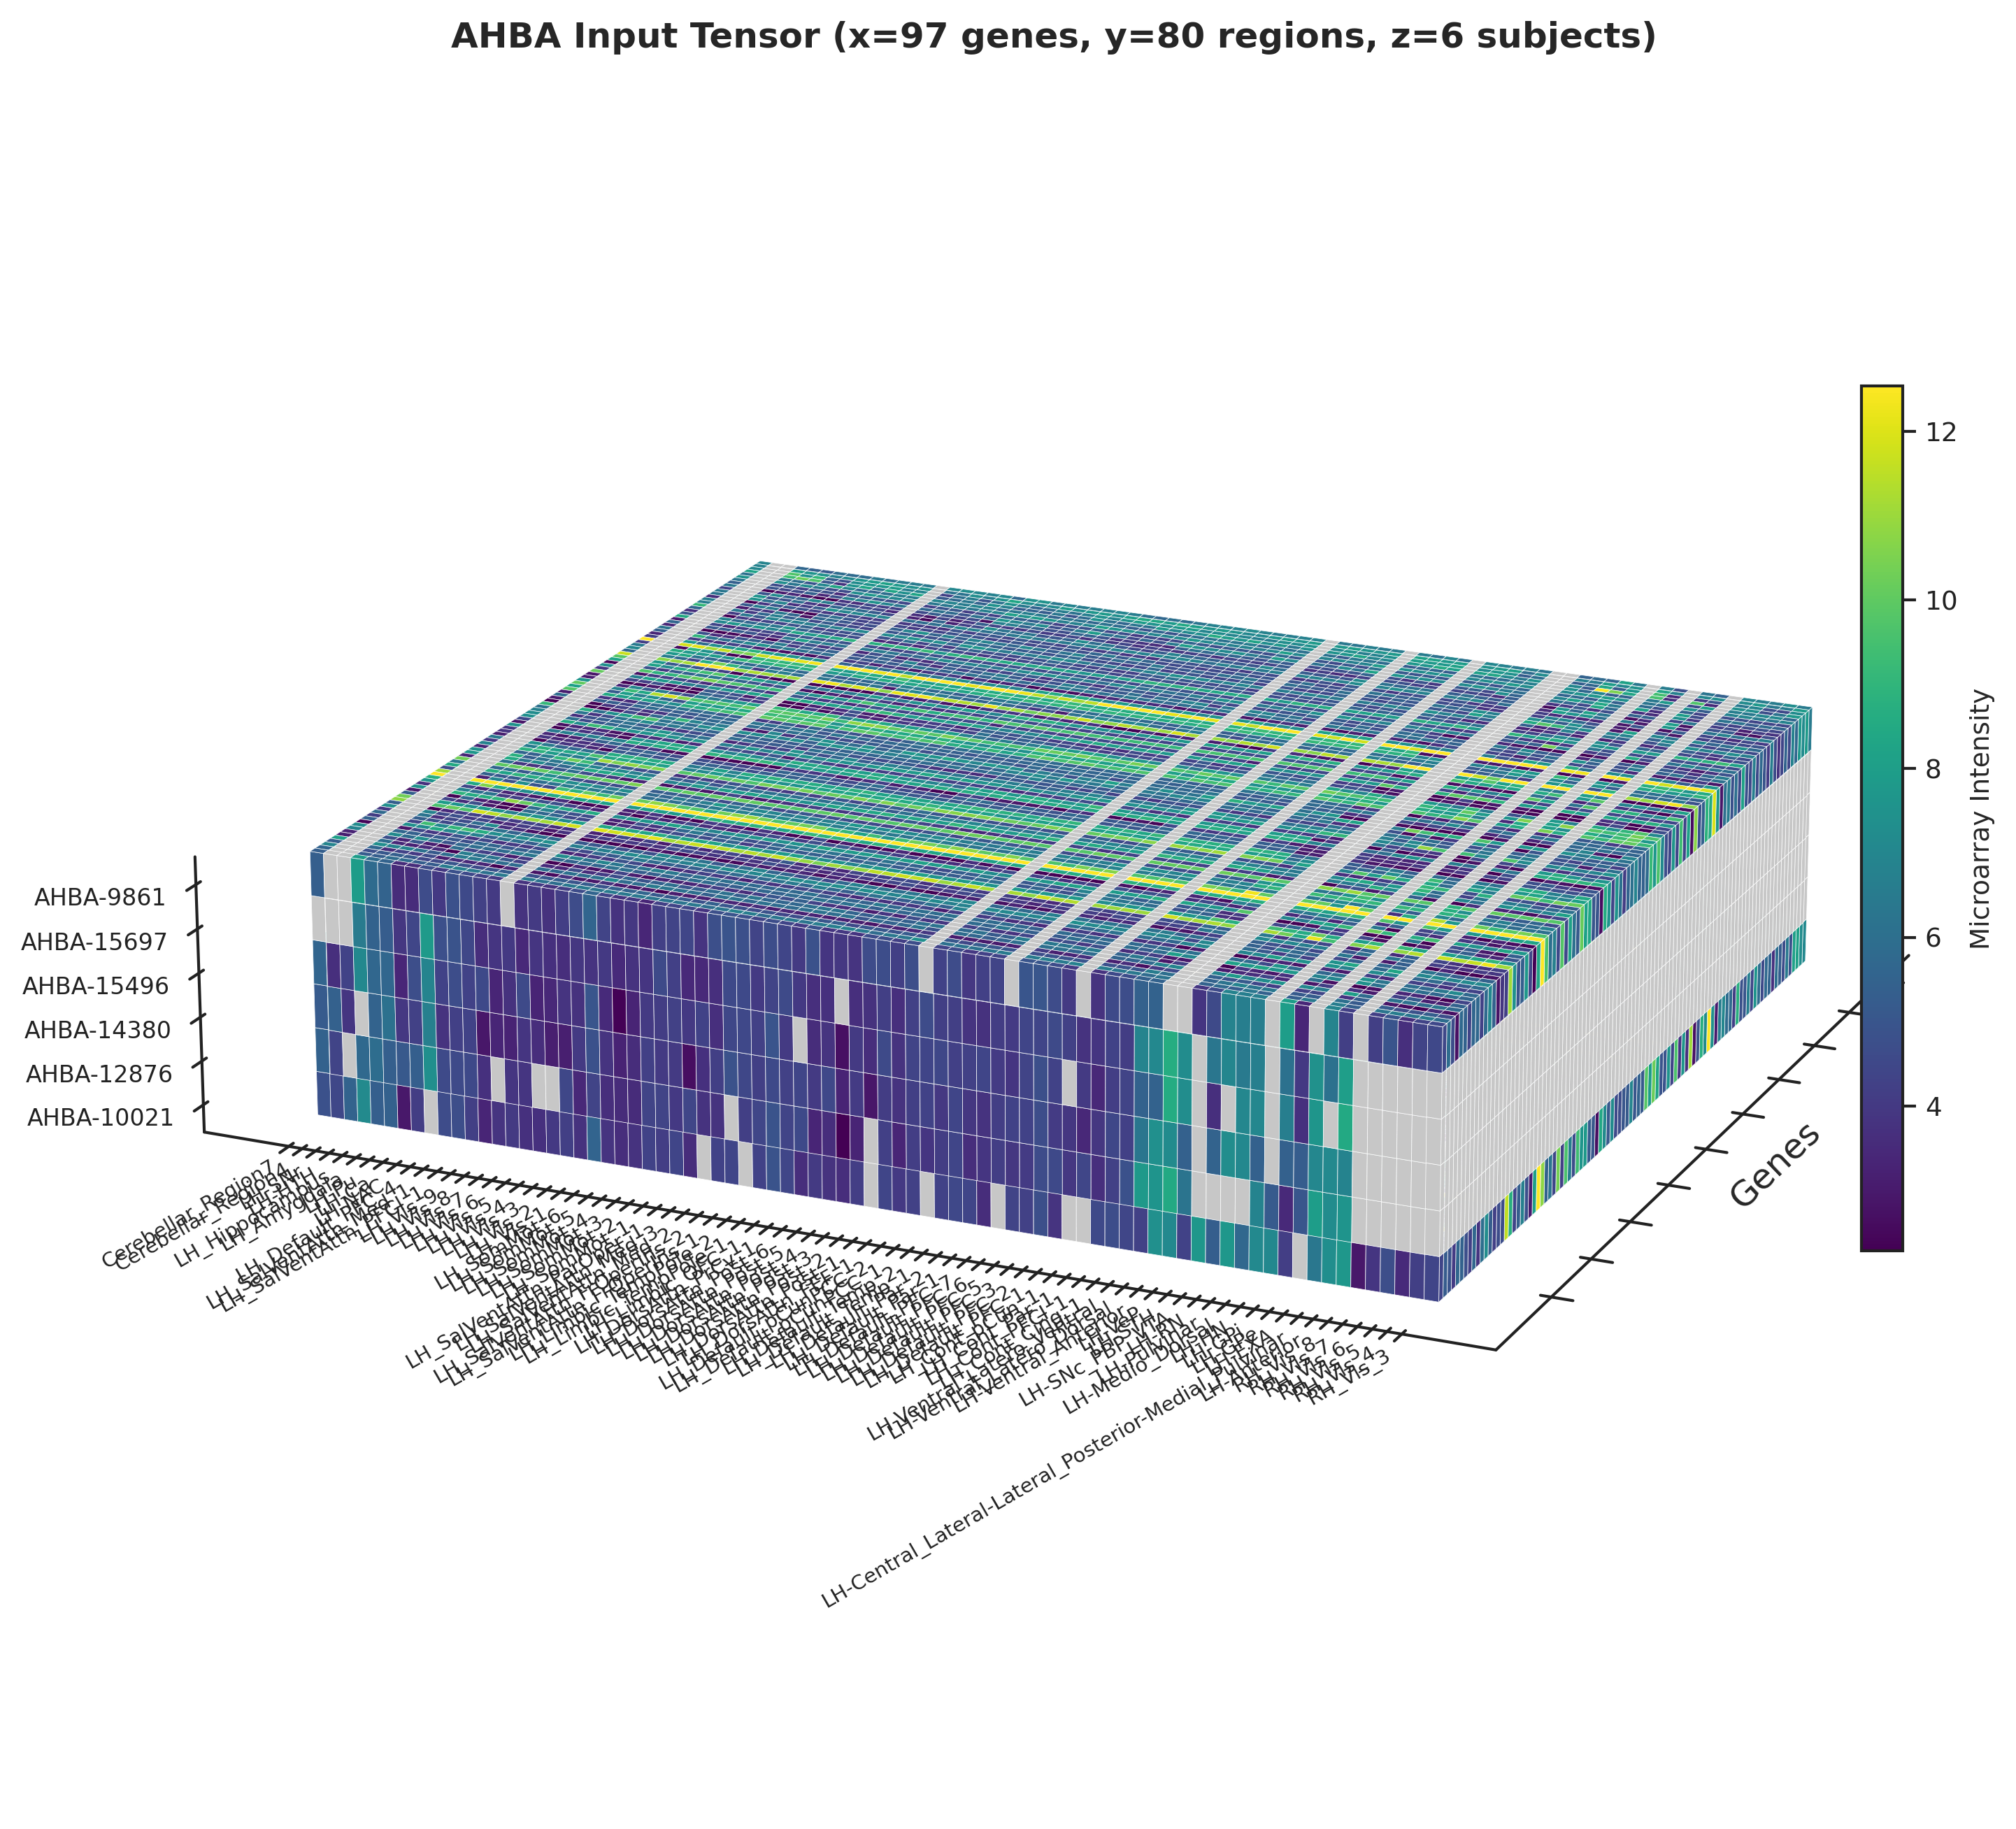

In [5]:
fig, ax = plot_gtex_tensor_voxels(
    ahba_self,
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP,
    region_tick_step=REGION_TICK_STEP, tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, show_legend=SHOW_LEGEND,
    mask_render_mode=MASK_RENDER_MODE,
)
plt.show()

## Assemble the joint tensor

`build_joint_tensor_view` validates that regions, genes, and `region_axis_kind` match, concatenates subjects along axis 0, records per-dataset `dataset_slices`, and derives `matched_region_count`.

In [6]:
SMALL = True
CSV_PATH = Path('data/raw/gxp_samples.csv')
ACTIVE_GENE_LIST = 'richiardi2015'  # richiardi2015, allgenes_stable_r0.2

# Region frame: 'region_matched_superset' so both datasets share the AHBA axis
# (GTEx superset returns the AHBA axis with future_imputation_mask on padded cells).
REGION_ORDERING = 'region_matched_superset'
MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'

# SMALL preset mirrors eval_gxp_samples_combat.ipynb for A/B comparability.
# SMALL=True   -> fast iteration (30 GTEx / 6 AHBA / 100 genes / 75 regions, DPI 300)
# SMALL=False  -> full-density figure (200 GTEx / 6 AHBA / full panel / full superset, DPI 400)
N_GTEX_SUBJECTS = 40 if SMALL else 200
N_AHBA_SUBJECTS = 6
N_GENES = 100 if SMALL else None
N_REGIONS = 80 if SMALL else None

MIN_REGIONS_PER_SUBJECT = 5
RANDOM_SEED = 42

# Subject-axis stacking: AHBA first (lower z) so GTEx renders on top.
STACK_ORDER = ('AHBA', 'GTEx')

# Render knobs
MISSING_ALPHA = 1.0
FUTURE_IMPUTATION_ALPHA = 0.3   # translucent gray on GTEx padded (no-data) cells
# 'two_pass'  -> opaque cells painted first, translucent slab overlaid (cleaner seam)
# 'single_pass' -> original behavior; one voxel call with mixed alphas (shows the artifact)
MASK_RENDER_MODE = 'single_pass'

FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 300 if SMALL else 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0

SUBJECT_TICK_STEP = 1
GENE_TICK_STEP = 10
REGION_TICK_STEP = 1
TICK_LABEL_PAD = -3.0

SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'

SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False

SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False

SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = False
DATASET_GAP = 1

In [7]:
common_kwargs = dict(
    region_ordering=REGION_ORDERING,
    gene_panel=ACTIVE_GENE_LIST,
    n_regions=N_REGIONS,
    n_genes=N_GENES,
    min_regions_per_subject=MIN_REGIONS_PER_SUBJECT,
    random_seed=RANDOM_SEED,
    matching_policy=MATCHING_POLICY,
    matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    gtex_rep_mode=GTEX_REP_MODE,
    gtex_hemi_mode=GTEX_HEMI_MODE,
)

gtex_view = build_native_tensor_view(CSV_PATH, dataset='GTEx', n_subjects=N_GTEX_SUBJECTS, **common_kwargs)
ahba_view = build_native_tensor_view(CSV_PATH, dataset='AHBA', n_subjects=N_AHBA_SUBJECTS, **common_kwargs)

print(f'GTEx values: {gtex_view.values.shape}   region_axis_kind={gtex_view.region_axis_kind}   stage={gtex_view.pipeline_stage!r}')
print(f'AHBA values: {ahba_view.values.shape}   region_axis_kind={ahba_view.region_axis_kind}   stage={ahba_view.pipeline_stage!r}')
print(f'shared regions identical: {gtex_view.regions == ahba_view.regions}')
print(f'shared genes identical:   {gtex_view.genes   == ahba_view.genes}')
print(f'GTEx future-imputation cols: {int(gtex_view.future_imputation_mask.any(axis=0).sum())}')
print(f'AHBA future-imputation cols: {int(ahba_view.future_imputation_mask.any(axis=0).sum())}')

/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:868: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:868: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


GTEx values: (40, 80, 97)   region_axis_kind=ahba_parcel   stage='native_parcel'
AHBA values: (6, 80, 97)   region_axis_kind=ahba_parcel   stage='native_parcel'
shared regions identical: True
shared genes identical:   True
GTEx future-imputation cols: 68
AHBA future-imputation cols: 0


In [8]:
joint_view = build_joint_tensor_view(gtex_view, ahba_view, stack_order=STACK_ORDER)

print(f'joint values: {joint_view.values.shape}  (subjects x regions x genes)')
print(f'dataset_slices: {joint_view.dataset_slices}')
print(f'matched_region_count: {joint_view.matched_region_count}')
print(f'region_axis_kind: {joint_view.region_axis_kind}')

joint values: (46, 80, 97)  (subjects x regions x genes)
dataset_slices: {'AHBA': slice(0, 6, None), 'GTEx': slice(6, 46, None)}
matched_region_count: 12
region_axis_kind: ahba_parcel


## Render the raw joint tensor

Per-dataset min-max normalization with a single shared colorbar. GTEx future-imputation cells render translucent; AHBA unobserved cells render solid gray; `dataset_gap` separates the two subject blocks.

In [9]:
SMALL = True
CSV_PATH = Path('data/raw/gxp_samples.csv')
ACTIVE_GENE_LIST = 'richiardi2015'  # richiardi2015, allgenes_stable_r0.2

# Region frame: 'region_matched_superset' so both datasets share the AHBA axis
# (GTEx superset returns the AHBA axis with future_imputation_mask on padded cells).
REGION_ORDERING = 'region_matched_superset'
MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'

# SMALL preset mirrors eval_gxp_samples_combat.ipynb for A/B comparability.
# SMALL=True   -> fast iteration (30 GTEx / 6 AHBA / 100 genes / 75 regions, DPI 300)
# SMALL=False  -> full-density figure (200 GTEx / 6 AHBA / full panel / full superset, DPI 400)
N_GTEX_SUBJECTS = 40 if SMALL else 200
N_AHBA_SUBJECTS = 6
N_GENES = 100 if SMALL else None
N_REGIONS = 80 if SMALL else None

MIN_REGIONS_PER_SUBJECT = 5
RANDOM_SEED = 42

# Subject-axis stacking: AHBA first (lower z) so GTEx renders on top.
STACK_ORDER = ('AHBA', 'GTEx')

# Render knobs
MISSING_ALPHA = 1.0
FUTURE_IMPUTATION_ALPHA = 0.3   # translucent gray on GTEx padded (no-data) cells
# 'two_pass'  -> opaque cells painted first, translucent slab overlaid (cleaner seam)
# 'single_pass' -> original behavior; one voxel call with mixed alphas (shows the artifact)
MASK_RENDER_MODE = 'two_pass'

FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 300 if SMALL else 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0

SUBJECT_TICK_STEP = 2
GENE_TICK_STEP = 10
REGION_TICK_STEP = 3
TICK_LABEL_PAD = -3.0

SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'

SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False

SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False

SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = True
DATASET_GAP = 1

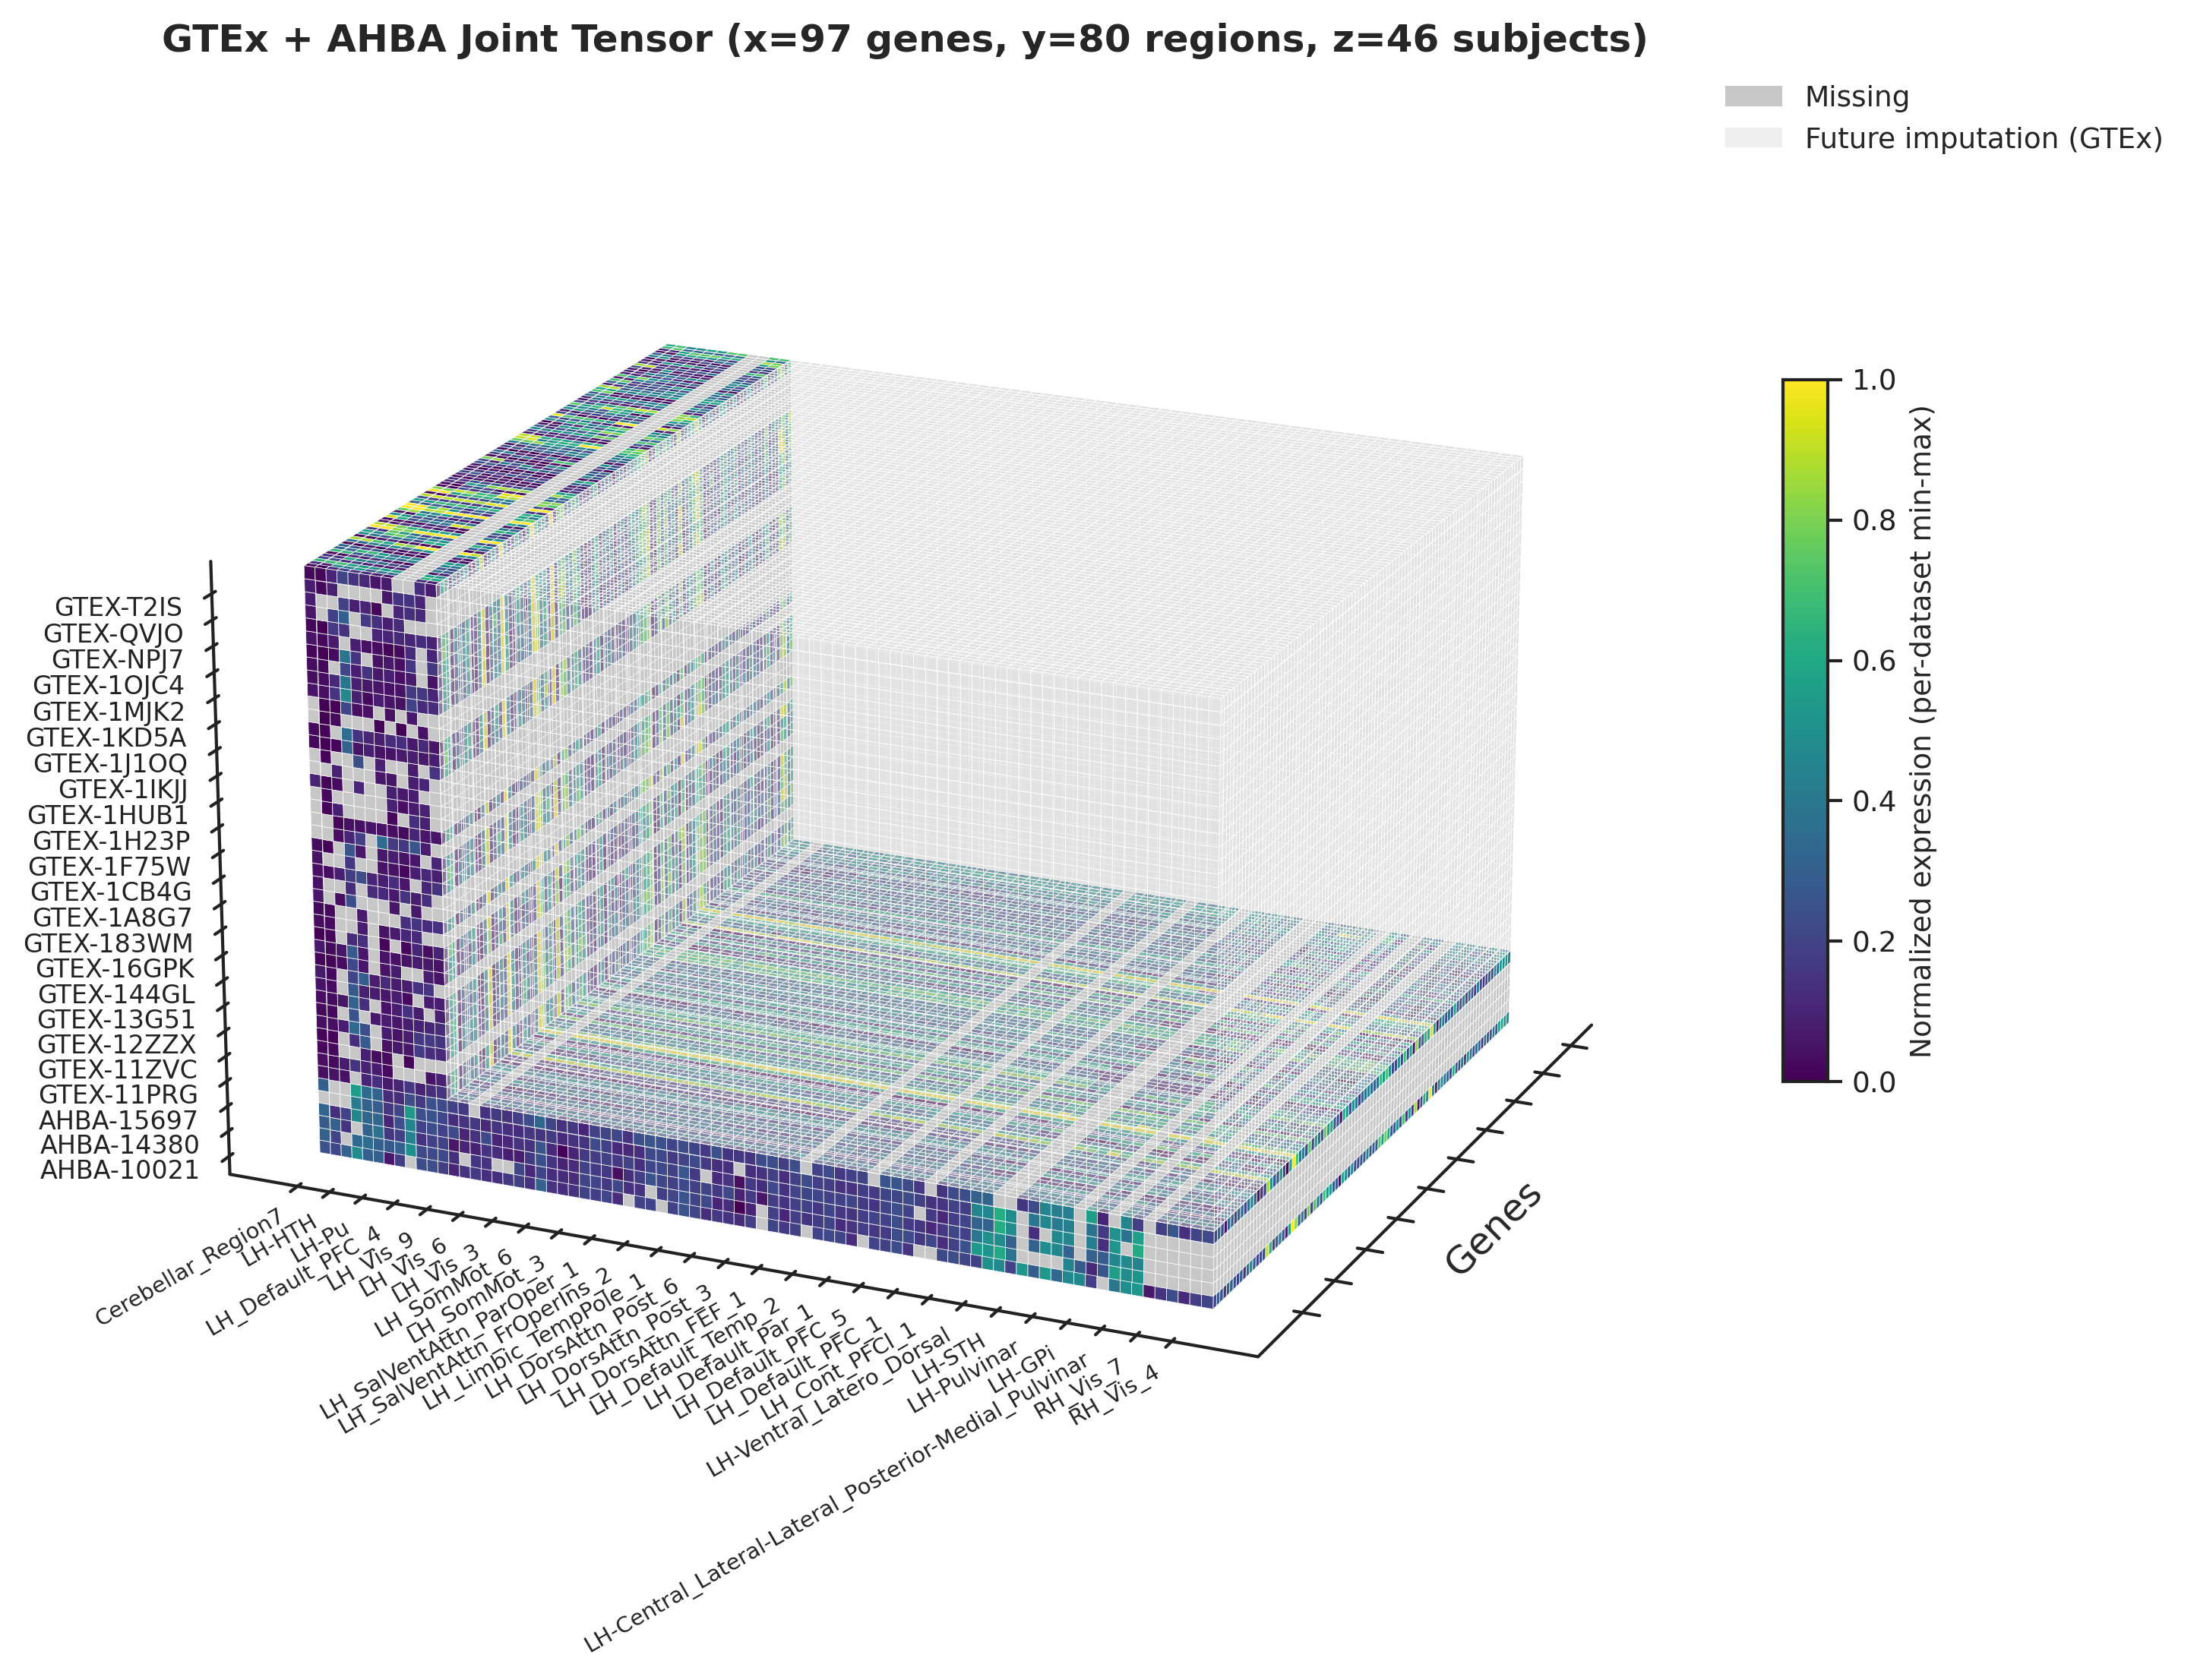

{'AHBA': (2.2794676113128665, 12.53882453918457),
 'GTEx': (0.01533816576004028, 5.363430175781245)}

In [10]:
fig, ax = plot_joint_tensor_voxels(
    joint_view,
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP,
    region_tick_step=REGION_TICK_STEP, tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, show_legend=SHOW_LEGEND,
    dataset_gap=DATASET_GAP, mask_render_mode=MASK_RENDER_MODE,
)
plt.show()
ax._joint_dataset_ranges

## Next

- ComBat pre/post joint: `eval_gxp_samples_combat.ipynb`
- LORO + full-fit predictions: `eval_gxp_samples_predictions.ipynb`